<a href="https://colab.research.google.com/github/jessicajordan31/Data-Mining-Project/blob/main/DataMiningFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sujaykapadnis/new-york-times-bestsellers")

print("Path to dataset files:", path)

100%|██████████| 605k/605k [00:00<00:00, 28.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sujaykapadnis/new-york-times-bestsellers/versions/1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#from sklearn.neighbors import NearestNeighbors #prob need later
#from sklearn.preprocessing import StandardScaler


In [ ]:
full = pd.read_csv(f'{path}/nyt_full.tsv', sep='\t')
full.head()
#full.info()

,year,week,rank,title_id,title,author
0,1931,1931-10-12,1,6477,THE TEN COMMANDMENTS,Warwick Deeping
1,1931,1931-10-12,2,1808,FINCHE'S FORTUNE,Mazo de la Roche
2,1931,1931-10-12,3,5304,THE GOOD EARTH,Pearl S. Buck
3,1931,1931-10-12,4,4038,SHADOWS ON THE ROCK,Willa Cather
4,1931,1931-10-12,5,3946,SCARMOUCHE THE KING MAKER,Rafael Sabatini


In [ ]:
titles = pd.read_csv(f'{path}/nyt_titles.tsv', sep='\t')
titles.head()

,id,title,author,year,total_weeks,first_week,debut_rank,best_rank
0,0,"""H"" IS FOR HOMICIDE",Sue Grafton,1991,15,1991-05-05,1,2
1,1,"""I"" IS FOR INNOCENT",Sue Grafton,1992,11,1992-04-26,14,2
2,10,''G'' IS FOR GUMSHOE,Sue Grafton,1990,6,1990-05-06,4,8
3,100,A DOG'S JOURNEY,W. Bruce Cameron,2012,1,2012-05-27,3,14
4,1000,CHANGING FACES,Kimberla Lawson Roby,2006,1,2006-02-19,11,14


7.0
4.0


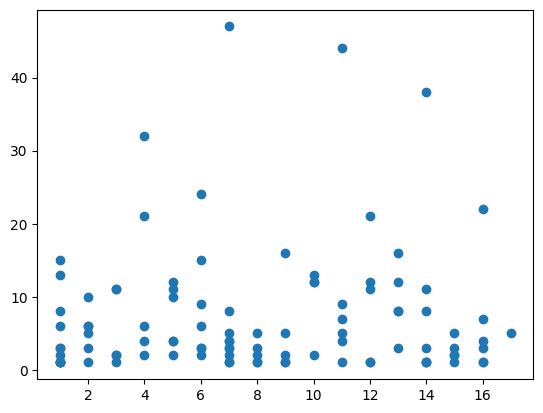

In [ ]:
# Figure 1. scatterplot for Comparing Duration by Debut Rank
# using nyt_titles.tsv file debut_rank and total_weeks vars

mini_titles=titles.head(100)

debut_rank = mini_titles[['debut_rank']]
total_weeks = mini_titles[['total_weeks']]

print(np.median(debut_rank))
print(np.median(total_weeks))

plt.scatter(debut_rank, total_weeks)



8.0
4.0


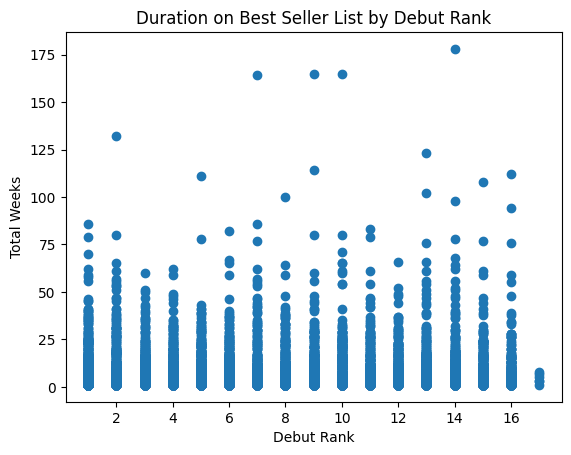

In [ ]:
#FULL
# Figure 1. scatterplot for Comparing Duration by Debut Rank
# using nyt_titles.tsv file debut_rank and total_weeks vars



debut_rank = titles[['debut_rank']]
total_weeks = titles[['total_weeks']]

print(np.median(debut_rank))
print(np.median(total_weeks))

plt.scatter(debut_rank, total_weeks)

plt.title("Duration on Best Seller List by Debut Rank")
plt.xlabel("Debut Rank")
plt.ylabel("Total Weeks")
plt.show()


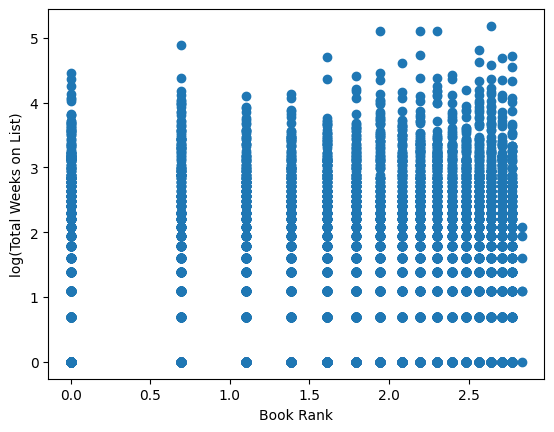

In [ ]:
#with logs
plt.scatter(np.log(titles['debut_rank']), np.log(titles['total_weeks']))
plt.xlabel("Book Rank")
plt.ylabel("log(Total Weeks on List)")
plt.show()

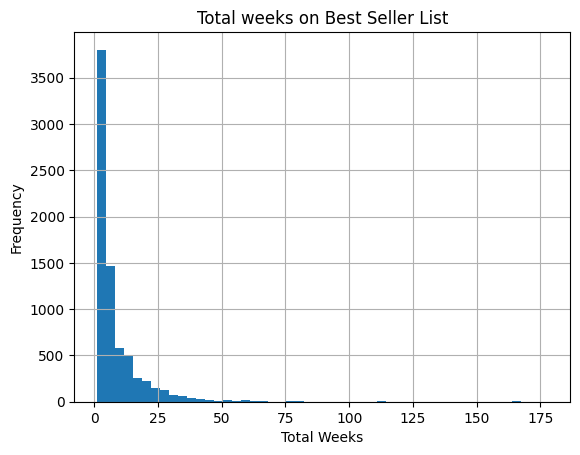

In [ ]:
#histogram
total_weeks = titles[['total_weeks']]

total_weeks.hist(bins=50)
plt.title("Total weeks on Best Seller List")
plt.xlabel("Total Weeks")
plt.ylabel("Frequency")
plt.show()

In [ ]:
titles.describe()

,id,year,total_weeks,debut_rank,best_rank
count,7431.000000,7431.000000,7431.000000,7431.000000,7431.000000
mean,3715.000000,1989.605168,8.126228,7.897726,6.914278
std,2145.289258,26.234540,11.208171,4.574437,4.567460
min,0.000000,1931.000000,1.000000,1.000000,1.000000
25%,1857.500000,1968.000000,2.000000,4.000000,3.000000
50%,3715.000000,2000.000000,4.000000,8.000000,6.000000
75%,5572.500000,2011.000000,10.000000,12.000000,10.000000
max,7430.000000,2020.000000,178.000000,17.000000,17.000000


In [ ]:
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7431 entries, 0 to 7430
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           7431 non-null   int64 
 1   title        7431 non-null   object
 2   author       7427 non-null   object
 3   year         7431 non-null   int64 
 4   total_weeks  7431 non-null   int64 
 5   first_week   7431 non-null   object
 6   debut_rank   7431 non-null   int64 
 7   best_rank    7431 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 464.6+ KB


In [ ]:
filtered_rows_loc = titles.loc[titles['total_weeks'] == 178]
print(filtered_rows_loc)

        id                      title     author  year  total_weeks  \
2606  3343  OH, THE PLACES YOU'LL GO!  Dr. Seuss  1990          178   

      first_week  debut_rank  best_rank  
2606  1990-02-25          14          1  


array([[<Axes: title={'center': 'debut_rank'}>]], dtype=object)

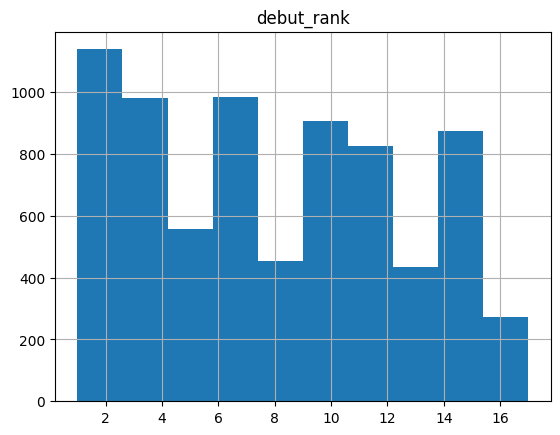

In [ ]:
#rank histogram
debut_rank = titles[['debut_rank']]

debut_rank.hist()

In [ ]:
# percent change in debut rank to best rank- this is wrong--> fix at somepoint
titles["percent_change"]=titles[['debut_rank', 'best_rank']].pct_change(axis=1)['best_rank'] * 100
titles.head(10)

,id,title,author,year,total_weeks,first_week,debut_rank,best_rank,percent_change
0,0,"""H"" IS FOR HOMICIDE",Sue Grafton,1991,15,1991-05-05,1,2,100.000000
1,1,"""I"" IS FOR INNOCENT",Sue Grafton,1992,11,1992-04-26,14,2,-85.714286
2,10,''G'' IS FOR GUMSHOE,Sue Grafton,1990,6,1990-05-06,4,8,100.000000
3,100,A DOG'S JOURNEY,W. Bruce Cameron,2012,1,2012-05-27,3,14,366.666667
4,1000,CHANGING FACES,Kimberla Lawson Roby,2006,1,2006-02-19,11,14,27.272727
5,1001,CHAOS,Patricia Cornwell,2016,3,2016-12-04,1,7,600.000000
6,1002,CHAPTERHOUSE: DUNE,Frank Herbert,1985,16,1985-04-21,9,2,-77.777778
7,1003,CHARADE,Sandra Brown,1994,5,1994-05-01,7,10,42.857143
8,1004,CHARLESTON,John Jakes,2002,4,2002-08-25,7,12,71.428571
9,1005,CHARLOTTE GRAY,Sebastian Faulks,1999,1,1999-03-14,12,17,41.666667


In [ ]:
#ai generated just to see
x = titles['debut_rank']
y = titles['total_weeks']

# real correlation
real_corr = np.corrcoef(x, y)[0,1]

# permutation test
random_corrs = []
for i in range(1000):
    shuffled_x = np.random.permutation(x)
    corr = np.corrcoef(shuffled_x, y)[0,1]
    random_corrs.append(corr)

print("Real correlation:", real_corr)
print("Average random correlation:", np.mean(random_corrs))
# both are basically 0, so there is no correlation

Real correlation: -6.317659122530448e-05
Average random correlation: 0.0002787397485140029


In [ ]:
#modern data

modern_titles= titles[titles['year']>=2015]
modern_titles


,id,title,author,year,total_weeks,first_week,debut_rank,best_rank,percent_change
5,1001,CHAOS,Patricia Cornwell,2016,3,2016-12-04,1,7,600.000000
24,1019,CHASING SUNSETS,Karen Kingsbury,2015,1,2015-04-26,16,14,-12.500000
25,102,A DOG'S WAY HOME,W. Bruce Cameron,2017,2,2017-05-28,9,10,11.111111
28,1022,CHERRY,Nico Walker,2018,1,2018-09-02,1,14,1300.000000
34,1028,CHILD'S PLAY,Danielle Steel,2019,1,2019-10-27,16,9,-43.750000
...,...,...,...,...,...,...,...,...,...
7390,962,CATALYST,James Luceno,2016,2,2016-12-04,4,10,150.000000
7396,968,CAVE OF BONES,Anne Hillerman,2018,1,2018-04-22,8,11,37.500000
7408,979,CELTIC EMPIRE,Clive Cussler and Dirk Cussler,2019,7,2019-04-07,13,3,-76.923077
7411,981,CEMETERY ROAD,Greg Iles,2019,5,2019-03-24,12,2,-83.333333


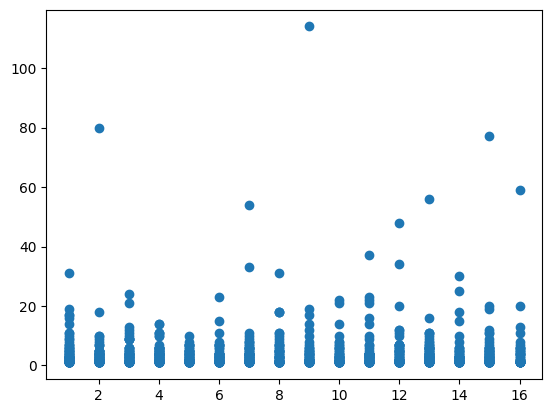

In [ ]:
#scatter for moden

rank=modern_titles[['debut_rank']]
weeks=modern_titles[['total_weeks']]

plt.scatter(rank, weeks)


array([[<Axes: title={'center': 'total_weeks'}>]], dtype=object)

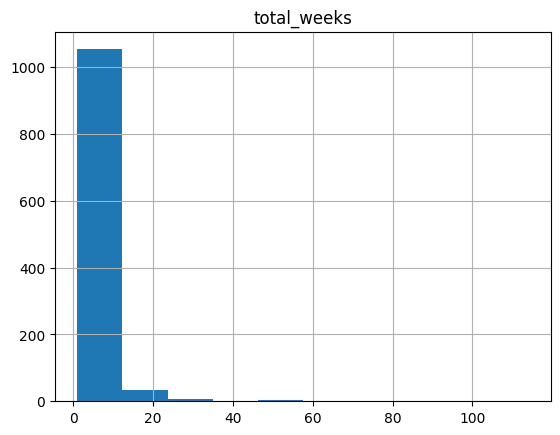

In [ ]:
#moden title debut rank histogram
total_weeks = modern_titles[['total_weeks']]

total_weeks.hist()

## Importing GoodReads datasets

In [ ]:
import json
import gzip
import os



In [ ]:
# mounted my google drive to get the GR datasets
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Placeholder for your first .json.gz file
file_path_1 = '/content/drive/MyDrive/DM_GR_datasets/goodreads_book_genres_initial.json.gz'

# Check if the file exists before attempting to open
if os.path.exists(file_path_1):
    with gzip.open(file_path_1, 'rt', encoding='utf-8') as f:
        data_1 = [json.loads(line) for line in f]
    print(f"Successfully loaded {len(data_1)} records from first_dataset.json.gz")
else:
    print(f"Error: File not found at {file_path_1}. Please update the file path.")


Successfully loaded 2360655 records from first_dataset.json.gz


In [ ]:
import pandas as pd
genres_df = pd.DataFrame(data_1)

# claude wrote this
# Extract genres as a sorted list (sorted by vote count, highest first) -- this is because some books have multiple genres
genres_df['genre_list'] = genres_df['genres'].apply(
    lambda d: sorted(d.keys(), key=lambda g: d[g], reverse=True) if isinstance(d, dict) else []
)

# Drop the raw dict column - we don't need it anymore
genres_df = genres_df.drop(columns=['genres'])

print(f"Shape: {genres_df.shape}")
print(genres_df.head(5))

Shape: (2360655, 2)
   book_id                                         genre_list
0  5333265           [history, historical fiction, biography]
1  1333909  [fiction, history, historical fiction, biography]
2  7327624  [fantasy, paranormal, fiction, mystery, thrill...
3  6066819       [fiction, romance, mystery, thriller, crime]
4   287140                                      [non-fiction]


In [ ]:
# normalize the NYT dataset

import re
import string

def normalize_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase, strip all punctuation, get rid of extra spaces
    text = text.lower()
    text = re.sub(rf"[{re.escape(string.punctuation)}]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Normalize NYT title and author
titles["title_norm"] = titles["title"].apply(normalize_text)
titles["author_norm"] = titles["author"].apply(normalize_text)

print(titles[["title", "author", "title_norm", "author_norm"]].head(5))

                  title                author         title_norm  \
0   "H" IS FOR HOMICIDE           Sue Grafton  h is for homicide   
1   "I" IS FOR INNOCENT           Sue Grafton  i is for innocent   
2  ''G'' IS FOR GUMSHOE           Sue Grafton   g is for gumshoe   
3       A DOG'S JOURNEY      W. Bruce Cameron     a dogs journey   
4        CHANGING FACES  Kimberla Lawson Roby     changing faces   

            author_norm  
0           sue grafton  
1           sue grafton  
2           sue grafton  
3       w bruce cameron  
4  kimberla lawson roby  


In [ ]:
# claude wrote this to pull in second goodreads file BUT because this one is huge,
# we only keep two reviews per book

file_path_2 = '/content/drive/MyDrive/DM_GR_datasets/goodreads_reviews_dedup.json.gz'

from collections import defaultdict

valid_book_ids = set(genres_df['book_id'].astype(str))
reviews_per_book = defaultdict(list)
MAX_REVIEWS_PER_BOOK = 2
skipped = 0

with gzip.open(file_path_2, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        try:
            record = json.loads(line)
            bid = str(record.get('book_id', ''))
            if bid in valid_book_ids:
                if len(reviews_per_book[bid]) < MAX_REVIEWS_PER_BOOK:
                    reviews_per_book[bid].append({
                        'book_id': bid,
                        'rating': record.get('rating'),
                        'review_text': record.get('review_text'),
                    })
        except json.JSONDecodeError:
            skipped += 1
            continue

        if i % 1_000_000 == 0 and i > 0:
            total_kept = sum(len(v) for v in reviews_per_book.values())
            print(f"  Scanned {i/1e6:.0f}M lines, kept {total_kept:,} reviews so far...")

total_kept = sum(len(v) for v in reviews_per_book.values())
print(f"\nDone. {total_kept:,} reviews across {len(reviews_per_book):,} books.")

reviews_df = pd.DataFrame(
    [r for records in reviews_per_book.values() for r in records]
)
reviews_df['book_id'] = reviews_df['book_id'].astype(str)
print(reviews_df.shape)
print(reviews_df.columns.tolist())

  Scanned 1M lines, kept 520,005 reviews so far...
  Scanned 2M lines, kept 849,598 reviews so far...
  Scanned 3M lines, kept 1,117,966 reviews so far...
  Scanned 4M lines, kept 1,355,129 reviews so far...
  Scanned 5M lines, kept 1,568,655 reviews so far...
  Scanned 6M lines, kept 1,755,992 reviews so far...
  Scanned 7M lines, kept 1,933,062 reviews so far...
  Scanned 8M lines, kept 2,090,180 reviews so far...
  Scanned 9M lines, kept 2,245,266 reviews so far...
  Scanned 10M lines, kept 2,398,643 reviews so far...
  Scanned 11M lines, kept 2,538,651 reviews so far...
  Scanned 12M lines, kept 2,678,569 reviews so far...
  Scanned 13M lines, kept 2,807,941 reviews so far...
  Scanned 14M lines, kept 2,919,670 reviews so far...
  Scanned 15M lines, kept 3,027,603 reviews so far...

Done. 3,109,915 reviews across 2,080,190 books.
(3109915, 3)
['book_id', 'rating', 'review_text']


In [ ]:
print(reviews_df.head(3))
print(f"\nNull review_text: {reviews_df['review_text'].isna().sum():,}")
print(f"Empty review_text: {(reviews_df['review_text'] == '').sum():,}")
print(f"Rating distribution:\n{reviews_df['rating'].value_counts().sort_index()}")

    book_id  rating                                        review_text
0  24375664       5  Mind blowingly cool. Best science fiction I've...
1  24375664       4  It took me 2 months to read the first 200 page...
2  18245960       5  This is a special book. It started slow for ab...

Null review_text: 0
Empty review_text: 1,207
Rating distribution:
rating
0     140349
1      92053
2     237257
3     673575
4    1027368
5     939313
Name: count, dtype: int64


In [ ]:
# Drop empty review text
reviews_df = reviews_df[reviews_df['review_text'] != ''].reset_index(drop=True)
print(f"After dropping empty reviews: {len(reviews_df):,} rows")

# Merge reviews with genres on book_id
reviews_genres_df = reviews_df.merge(genres_df, on='book_id', how='left')
print(f"After merging with genres: {reviews_genres_df.shape}")
print(f"Reviews with no genre match: {reviews_genres_df['genre_list'].isna().sum():,}")
print(reviews_genres_df.head(3))

After dropping empty reviews: 3,108,708 rows
After merging with genres: (3108708, 4)
Reviews with no genre match: 0
    book_id  rating                                        review_text  \
0  24375664       5  Mind blowingly cool. Best science fiction I've...   
1  24375664       4  It took me 2 months to read the first 200 page...   
2  18245960       5  This is a special book. It started slow for ab...   

                                          genre_list  
0                     [fiction, fantasy, paranormal]  
1                     [fiction, fantasy, paranormal]  
2  [fiction, fantasy, paranormal, mystery, thrill...  


Right now, there is no column in common between NYT and Goodreads. So, we need to use ANOTHER file :( but we will be strong. Pivot nation over here

In [ ]:
file_path_3 = '/content/drive/MyDrive/DM_GR_datasets/goodreads_books.json.gz'

with gzip.open(file_path_3, 'rt', encoding='utf-8') as f:
    peek = json.loads(next(f))
print(list(peek.keys()))
print(peek)

['isbn', 'text_reviews_count', 'series', 'country_code', 'language_code', 'popular_shelves', 'asin', 'is_ebook', 'average_rating', 'kindle_asin', 'similar_books', 'description', 'format', 'link', 'authors', 'publisher', 'num_pages', 'publication_day', 'isbn13', 'publication_month', 'edition_information', 'publication_year', 'url', 'image_url', 'book_id', 'ratings_count', 'work_id', 'title', 'title_without_series']
{'isbn': '0312853122', 'text_reviews_count': '1', 'series': [], 'country_code': 'US', 'language_code': '', 'popular_shelves': [{'count': '3', 'name': 'to-read'}, {'count': '1', 'name': 'p'}, {'count': '1', 'name': 'collection'}, {'count': '1', 'name': 'w-c-fields'}, {'count': '1', 'name': 'biography'}], 'asin': '', 'is_ebook': 'false', 'average_rating': '4.00', 'kindle_asin': '', 'similar_books': [], 'description': '', 'format': 'Paperback', 'link': 'https://www.goodreads.com/book/show/5333265-w-c-fields', 'authors': [{'author_id': '604031', 'role': ''}], 'publisher': "St. Ma

In [ ]:
books = []
with gzip.open(file_path_3, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        try:
            record = json.loads(line)
            books.append({
                'book_id': str(record.get('book_id', '')),
                'title': record.get('title_without_series', ''),
                'publisher': record.get('publisher', ''),
                'average_rating': record.get('average_rating', ''),
                'ratings_count': record.get('ratings_count', ''),
            })
        except json.JSONDecodeError:
            continue

        if i % 500_000 == 0 and i > 0:
            print(f"  Scanned {i/1e6:.1f}M lines...")

books_df = pd.DataFrame(books)
books_df['title_norm'] = books_df['title'].apply(normalize_text)
print(f"Done. {len(books_df):,} books loaded.")
print(books_df.head(3))

  Scanned 0.5M lines...
  Scanned 1.0M lines...
  Scanned 1.5M lines...
  Scanned 2.0M lines...
Done. 2,360,655 books loaded.
   book_id                                              title  \
0  5333265                        W.C. Fields: A Life on Film   
1  1333909                                        Good Harbor   
2  7327624  The Unschooled Wizard (Sun Wolf and Starhawk, ...   

                publisher average_rating ratings_count  \
0      St. Martin's Press           4.00             3   
1  Simon & Schuster Audio           3.23            10   
2  Nelson Doubleday, Inc.           4.03           140   

                                       title_norm  
0                        wc fields a life on film  
1                                     good harbor  
2  the unschooled wizard sun wolf and starhawk 12  


Now, we can start by checking NYT dataset for matching. There is an error in line249 (Step hen King instead of Stephen King), so we'll fix that and create a new column with normalized titles and author names

In [ ]:
short_titles = titles[titles['title_norm'].str.len() < 5][['title', 'title_norm', 'author', 'author_norm']]
print(f"Titles with fewer than 5 characters after normalization: {len(short_titles)}")
print(short_titles)

Titles with fewer than 5 characters after normalization: 101
     title title_norm            author       author_norm
88    CLEA       clea  Lawrence Durrell  lawrence durrell
124   COMA       coma        Robin Cook        robin cook
245   CUBA       cuba    Stephen Coonts    stephen coonts
249   CUJO       cujo     Step hen King     step hen king
250   CUJO       cujo      Stephen King      stephen king
...    ...        ...               ...               ...
7294  BURN       burn      Linda Howard      linda howard
7295  BURN       burn       Nevada Barr       nevada barr
7305  BURR       burr        Gore Vidal        gore vidal
7406  CELL       cell        Robin Cook        robin cook
7407  CELL       cell      Stephen King      stephen king

[101 rows x 4 columns]


In [ ]:
# Fix the typo in the NYT data
titles['author_norm'] = titles['author_norm'].str.replace('step hen king', 'stephen king', regex=False)

# Verify the fix
print(titles[titles['title_norm'] == 'cujo'][['title', 'author', 'author_norm']])

    title         author   author_norm
249  CUJO  Step hen King  stephen king
250  CUJO   Stephen King  stephen king


Merge with NYT

In [ ]:
# Merge NYT titles against GoodReads books on normalized title
matched = titles.merge(
    books_df[['book_id', 'title_norm', 'publisher', 'average_rating', 'ratings_count']],
    on='title_norm',
    how='inner'
)

print(f"NYT books: {len(titles):,}")
print(f"Matched books: {len(matched):,}")
print(f"Unique NYT titles matched: {matched['title_norm'].nunique():,}")
print(matched[['title', 'author', 'title_norm', 'publisher', 'average_rating', 'ratings_count']].head(5))

NYT books: 7,431
Matched books: 58,945
Unique NYT titles matched: 5,577
                 title       author         title_norm           publisher  \
0  "H" IS FOR HOMICIDE  Sue Grafton  h is for homicide  Random House Audio   
1  "H" IS FOR HOMICIDE  Sue Grafton  h is for homicide           Pan Books   
2  "H" IS FOR HOMICIDE  Sue Grafton  h is for homicide  Henry Holt and Co.   
3  "H" IS FOR HOMICIDE  Sue Grafton  h is for homicide                       
4  "H" IS FOR HOMICIDE  Sue Grafton  h is for homicide  Random House Audio   

  average_rating ratings_count  
0           3.89            69  
1           3.89            85  
2           3.89           222  
3           3.89            11  
4           3.89            33  


 5,577 out of 7,431 NYT books matched! That's roughly 75%, BUT NYT book matches multiple GoodReads editions with different publishers. So, we can keep the edition with the most ratings

In [ ]:
# Convert to numeric first
matched['ratings_count'] = pd.to_numeric(matched['ratings_count'], errors='coerce').fillna(0)
matched['average_rating'] = pd.to_numeric(matched['average_rating'], errors='coerce').fillna(0)

# Keep the GoodReads edition with the most ratings per NYT book
matched_dedup = matched.sort_values('ratings_count', ascending=False) \
                       .drop_duplicates(subset=['title_norm', 'author_norm'], keep='first') \
                       .reset_index(drop=True)

print(f"After deduplication: {len(matched_dedup):,} books")
print(matched_dedup[['title', 'author', 'publisher', 'average_rating', 'ratings_count']].head(5))

After deduplication: 5,795 books
                    title          author                         publisher  \
0   TO KILL A MOCKINGBIRD      Harper Lee  Harper Perennial Modern Classics   
1              THE HOBBIT  J.R.R. Tolkien                  Houghton Mifflin   
2  THE CATCHER IN THE RYE   J.D. Salinger                    Back Bay Books   
3             ANIMAL FARM   George Orwell                               NAL   
4        THE LOVELY BONES    Alice Sebold         Little, Brown and Company   

   average_rating  ratings_count  
0            4.26      3255518.0  
1            4.25      2099680.0  
2            3.79      2086945.0  
3            3.88      1928931.0  
4            3.78      1628726.0  


In [ ]:
# Merge matched NYT+books with reviews+genres on book_id
final_df = matched_dedup.merge(
    reviews_genres_df,
    on='book_id',
    how='inner'
)

print(f"Matched NYT books with reviews: {final_df['title_norm'].nunique():,}")
print(f"Total rows (one per review): {len(final_df):,}")
print(f"Columns: {final_df.columns.tolist()}")
print(final_df.head(3))

Matched NYT books with reviews: 5,505
Total rows (one per review): 10,499
Columns: ['id', 'title', 'author', 'year', 'total_weeks', 'first_week', 'debut_rank', 'best_rank', 'percent_change', 'title_norm', 'author_norm', 'book_id', 'publisher', 'average_rating', 'ratings_count', 'rating', 'review_text', 'genre_list']
     id                  title          author  year  total_weeks  first_week  \
0  6887  TO KILL A MOCKINGBIRD      Harper Lee  1960           98  1960-08-07   
1  6887  TO KILL A MOCKINGBIRD      Harper Lee  1960           98  1960-08-07   
2  5398             THE HOBBIT  J.R.R. Tolkien  1977            2  1977-12-18   

   debut_rank  best_rank  percent_change             title_norm  author_norm  \
0          14          2      -85.714286  to kill a mockingbird   harper lee   
1          14          2      -85.714286  to kill a mockingbird   harper lee   
2           3         12      300.000000             the hobbit  jrr tolkien   

  book_id                         pu

In [ ]:
final_df.info()
final_df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10499 entries, 0 to 10498
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10499 non-null  int64  
 1   title           10499 non-null  object 
 2   author          10499 non-null  object 
 3   year            10499 non-null  int64  
 4   total_weeks     10499 non-null  int64  
 5   first_week      10499 non-null  object 
 6   debut_rank      10499 non-null  int64  
 7   best_rank       10499 non-null  int64  
 8   percent_change  10499 non-null  float64
 9   title_norm      10499 non-null  object 
 10  author_norm     10499 non-null  object 
 11  book_id         10499 non-null  object 
 12  publisher       10499 non-null  object 
 13  average_rating  10499 non-null  float64
 14  ratings_count   10499 non-null  float64
 15  rating          10499 non-null  int64  
 16  review_text     10499 non-null  object 
 17  genre_list      10499 non-null 

,id,title,author,year,total_weeks,first_week,debut_rank,best_rank,percent_change,title_norm,author_norm,book_id,publisher,average_rating,ratings_count,rating,review_text,genre_list
0,6887,TO KILL A MOCKINGBIRD,Harper Lee,1960,98,1960-08-07,14,2,-85.714286,to kill a mockingbird,harper lee,2657,Harper Perennial Modern Classics,4.26,3255518.0,5,Still relevant and beautiful.,"[fiction, history, historical fiction, biograp..."
1,6887,TO KILL A MOCKINGBIRD,Harper Lee,1960,98,1960-08-07,14,2,-85.714286,to kill a mockingbird,harper lee,2657,Harper Perennial Modern Classics,4.26,3255518.0,4,"R.I.P. Ms. Harper Lee, Feb. 19, 2016. Thank yo...","[fiction, history, historical fiction, biograp..."
2,5398,THE HOBBIT,J.R.R. Tolkien,1977,2,1977-12-18,3,12,300.000000,the hobbit,jrr tolkien,5907,Houghton Mifflin,4.25,2099680.0,1,Couldn't finish it. I was 5/6 of the way done ...,"[fantasy, paranormal, young-adult, fiction, ch..."
3,5398,THE HOBBIT,J.R.R. Tolkien,1977,2,1977-12-18,3,12,300.000000,the hobbit,jrr tolkien,5907,Houghton Mifflin,4.25,2099680.0,4,Really enjoyed this book! \n J.R.R. Tolkien is...,"[fantasy, paranormal, young-adult, fiction, ch..."
4,4792,THE CATCHER IN THE RYE,J.D. Salinger,1951,29,1951-07-29,15,4,-73.333333,the catcher in the rye,jd salinger,5107,Back Bay Books,3.79,2086945.0,3,"Certainly not his best, but it's Salinger so I...","[fiction, young-adult, history, historical fic..."


WOOOHOOO!!!

fully integrated dataset: 5,505 NYT books with reviews, 10,499 total rows, and all the columns we need for the model

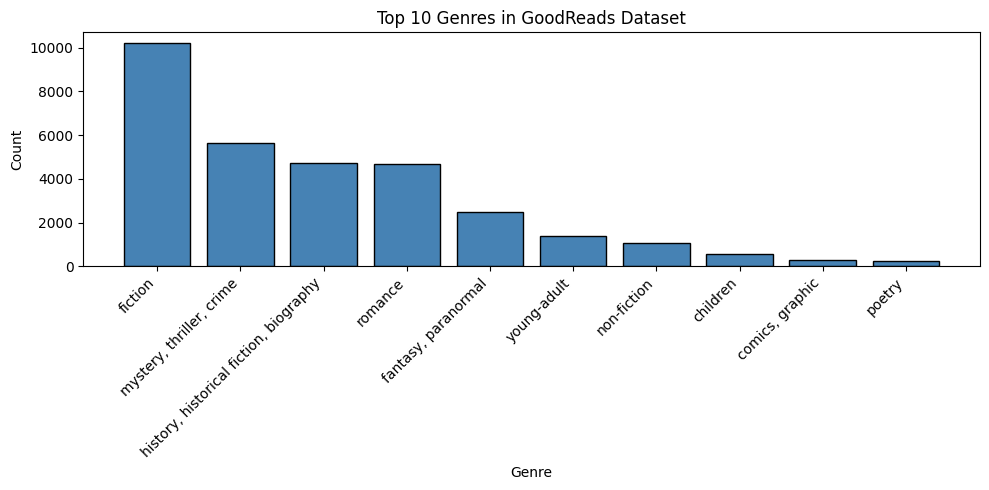

In [ ]:
all_genres = np.array([genre for genres in final_df['genre_list'] for genre in genres])

unique_genres, counts = np.unique(all_genres, return_counts=True)

sorted_idx = np.argsort(counts)[::-1][:10]
top_genres = unique_genres[sorted_idx]
top_counts = counts[sorted_idx]

plt.figure(figsize=(10, 5))
plt.bar(top_genres, top_counts, color='steelblue', edgecolor='black')
plt.title('Top 10 Genres in GoodReads Dataset')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('goodreads_genre_dist.png', dpi=150)
plt.show()

In [ ]:
# clean raw review text and preprocess reviews into review_clean df
import re
from sklearn.feature_extraction.text import TfidfVectorizer

def clean_review(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # remove newlines, punctuation, numbers and extra spaces
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

final_df['review_clean'] = final_df['review_text'].apply(clean_review)

In [ ]:
# create TF-IDF matrix from review_clean and now do feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    'im', 'ive', 'dont', 'didnt', 'doesnt', 'wasnt', 'isnt', 'wouldnt',
    'couldnt', 'shouldnt', 'wont', 'cant', 'id', 'youre', 'theyre',
    'thats', 'its', 'hed', 'shed', 'wed', 'youll', 'theyll',
    'book', 'read', 'reading', 'books', 'novel', 'author', 'story'
})

# sklearn has auto tf-idf (https://www.geeksforgeeks.org/machine-learning/sklearn-feature-extraction-with-tf-idf/)
tfidf = TfidfVectorizer(
    stop_words=list(custom_stopwords),   # removes common words  ("the", "a", "of") from previous dataset
    max_features=1000,      # cap vocabulary size, since we have 10,499 reviews, we only want important terms and no repeats
    min_df=2,               # ignore terms appearing in fewer than 2 reviews (potentially change..?)
    max_df=0.95,            # ignore terms appearing in more than 95% of reviews (too common, won't give us insight into meaning/sentiment)
    ngram_range=(1, 2),     # include single words and two-word phrases
)

# fit the model to the matrix
tfidf_matrix = tfidf.fit_transform(final_df['review_clean'])

#overview of shape and whatnot
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  Rows = reviews: {tfidf_matrix.shape[0]:,}")
print(f"  Cols = unique terms: {tfidf_matrix.shape[1]:,}")
print(f"Sample terms: {tfidf.get_feature_names_out()[:20]}")

TF-IDF matrix shape: (10499, 1000)
  Rows = reviews: 10,499
  Cols = unique terms: 1,000
Sample terms: ['ability' 'able' 'absolutely' 'account' 'act' 'action' 'actions' 'actual'
 'actually' 'add' 'added' 'addition' 'admit' 'adult' 'adventure'
 'adventures' 'affair' 'age' 'agent' 'ago']


Moving onto SVD - we want to see how much of the OG information is preserved after compressing dataset. We'll need to add to our limitations section that the small number of reviews per book (due to the 2-review cap) directly limits how much latent structure SVD can find.

We can try to increase number of reviews per book on Anvil once we get this down for the most part

In [ ]:
# compress each review from 1,000 dimensions (one per TF-IDF term) down to 200 dimensions
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html
# only use 200, regular SVD made Colab crash. This captures the top 200 components without calculating the rest
svd = TruncatedSVD(n_components=200, random_state=42)
# compressed representation by finding 200 most important patterns from components and shrinks each review.
review_embeddings = svd.fit_transform(tfidf_matrix)

print(f"TF-IDF matrix: {tfidf_matrix.shape}")
print(f"SVD embeddings: {review_embeddings.shape}")
print(f"Explained variance: {svd.explained_variance_ratio_.sum():.2%}")

TF-IDF matrix: (10499, 1000)
SVD embeddings: (10499, 200)
Explained variance: 49.70%


aggregate from review-level to book-level BEFORE KNN to get one row per book instead of one row per review

In [ ]:
# Create SVD columns to label them (basically adding the NYT set again)
svd_cols = [f'svd_{i}' for i in range(200)]
# review_embeddings is just a raw numpy array with no labels, so
# we stick book_id back on because SVD stripped away all the original columns
# and we want to identify it

embeddings_df = pd.DataFrame(review_embeddings, columns=svd_cols)
# add book_id back
embeddings_df['book_id'] = final_df['book_id'].values
# Average the embeddings across reviews for each book to combine sentiment of all reviews for that book
book_embeddings = embeddings_df.groupby('book_id')[svd_cols].mean().reset_index()
# Merge back with NYT metadata (one row per book)
model_df = matched_dedup[['book_id', 'title', 'author', 'total_weeks',
                           'debut_rank', 'best_rank', 'year',
                           'publisher', 'average_rating', 'ratings_count']].merge(
    book_embeddings, on='book_id', how='inner'
)


print(f"Model dataset shape: {model_df.shape}")
print(f"Unique books: {len(model_df):,}")
print(model_df[['title', 'author', 'total_weeks', 'average_rating']].head(5))

Model dataset shape: (5722, 210)
Unique books: 5,722
                    title          author  total_weeks  average_rating
0   TO KILL A MOCKINGBIRD      Harper Lee           98            4.26
1              THE HOBBIT  J.R.R. Tolkien            2            4.25
2  THE CATCHER IN THE RYE   J.D. Salinger           29            3.79
3             ANIMAL FARM   George Orwell            6            3.88
4        THE LOVELY BONES    Alice Sebold           65            3.78


In [ ]:
# component analysis
# this gets all 1000 vocab words we got
feature_names = tfidf.get_feature_names_out()
# explained is an array of 200 numbers for each component to show how much variance each caputres
explained = svd.explained_variance_ratio_
# keep only 50 first indexes of largest informative components
top_var_indices = np.argsort(explained)[::-1]
top_50 = top_var_indices[:50]

# this is checking how much each dimension correlates with total_weeks.
# maybe something to consider changing as well
correlations = []
for i in top_50:
    corr = np.corrcoef(model_df[f'svd_{i}'], model_df['total_weeks'])[0, 1]
    correlations.append((i, abs(corr)))

# gets top five values associated with bestselling duration
top_corr = sorted(correlations, key=lambda x: x[1], reverse=True)
top_components = [i for i, _ in top_corr[:5]]

# helper to find most extreme words on high end and low end
# then we have to find them in the feature names array
def get_top_words(component_index, n=10):
    component = svd.components_[component_index]
    top_high = np.argsort(component)[::-1][:n]
    top_low = np.argsort(component)[:n]
    high_words = [feature_names[i] for i in top_high]
    low_words = [feature_names[i] for i in top_low]
    return high_words, low_words

for comp in top_components:
    corr_val = next(c for i, c in top_corr if i == comp)
    high, low = get_top_words(comp)
    print(f"\nComponent {comp}  (correlation with total_weeks: {corr_val:.4f})")
    print(f"  High end: {high}")
    print(f"  Low end:  {low}")


Component 8  (correlation with total_weeks: 0.1086)
  High end: ['favorite', 'time', 'just', 'really', 'ago', 'years', 'long', 'long time', 'reread', 'years ago']
  Low end:  ['series', 'like', 'characters', 'interesting', 'plot', 'character', 'love', 'bit', 'main', 'fun']

Component 5  (correlation with total_weeks: 0.1035)
  High end: ['really', 'enjoyed', 'really enjoyed', 'love', 'series', 'liked', 'just', 'like', 'really liked', 'really good']
  Low end:  ['life', 'time', 'man', 'years', 'war', 'world', 'family', 'best', 'people', 'young']

Component 18  (correlation with total_weeks: 0.0777)
  High end: ['written', 'really', 'interesting', 'years', 'ago', 'fun', 'years ago', 'beautifully', 'liked', 'series']
  Low end:  ['enjoyed', 'did', 'little', 'bit', 'end', 'review', 'best', 'stories', 'going', 'excellent']

Component 22  (correlation with total_weeks: 0.0663)
  High end: ['movie', 'excellent', 'better', 'think', 'character', 'way', 'interesting', 'plot', 'fun', 'know']
  L

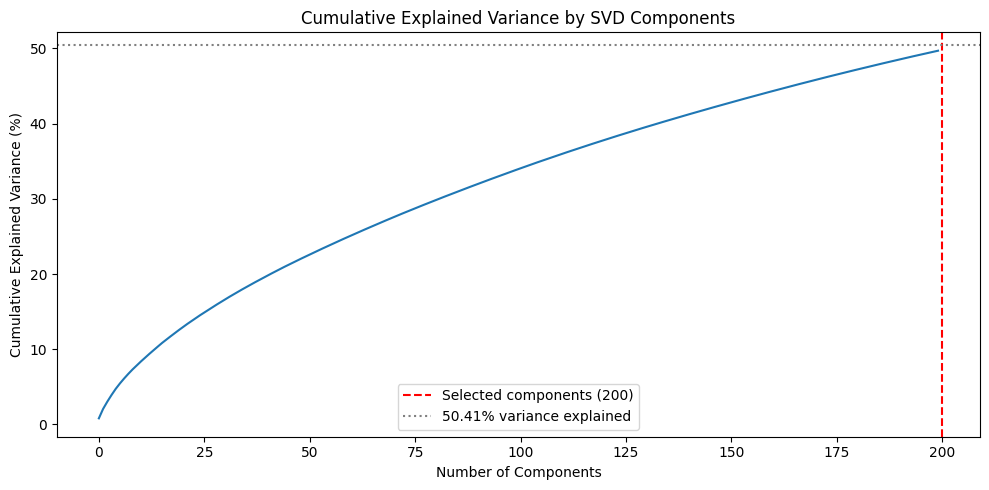

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(svd.explained_variance_ratio_) * 100)
plt.axvline(x=200, color='red', linestyle='--', label='Selected components (200)')
plt.axhline(y=50.41, color='gray', linestyle=':', label='50.41% variance explained')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Explained Variance by SVD Components')
plt.legend()
plt.tight_layout()
plt.savefig('svd_variance.png', dpi=150)
plt.show()

Next steps: write train/test split and then KNN regression using model_df. How are we actually incorporating NYT dataset?

In [ ]:
model_df

,book_id,title,author,total_weeks,debut_rank,best_rank,year,publisher,average_rating,ratings_count,...,svd_190,svd_191,svd_192,svd_193,svd_194,svd_195,svd_196,svd_197,svd_198,svd_199
0,2657,TO KILL A MOCKINGBIRD,Harper Lee,98,14,2,1960,Harper Perennial Modern Classics,4.26,3255518.0,...,0.016029,0.036088,-0.004752,-0.007924,0.016480,0.005914,0.000711,0.027936,0.026855,-0.006957
1,5907,THE HOBBIT,J.R.R. Tolkien,2,3,12,1977,Houghton Mifflin,4.25,2099680.0,...,0.019525,-0.024525,0.000547,0.016487,-0.010539,0.031181,-0.019863,-0.047271,-0.011996,-0.002785
2,5107,THE CATCHER IN THE RYE,J.D. Salinger,29,15,4,1951,Back Bay Books,3.79,2086945.0,...,0.014253,-0.007399,-0.052365,-0.015058,-0.006903,0.005994,0.041179,-0.004935,-0.031088,-0.032658
3,7613,ANIMAL FARM,George Orwell,6,8,7,1946,NAL,3.88,1928931.0,...,-0.025969,0.016857,-0.002282,-0.033932,-0.054331,0.033730,0.005524,-0.041141,0.004984,-0.009703
4,12232938,THE LOVELY BONES,Alice Sebold,65,6,1,2002,"Little, Brown and Company",3.78,1628726.0,...,0.041229,-0.013931,0.017307,-0.029490,-0.003003,-0.025205,0.031644,-0.014800,0.021528,-0.009016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5717,13505343,A DREAM OF KINGS,Davis Grubb,1,15,15,1955,Charles Scribner's Sons,3.20,1.0,...,0.113605,-0.039898,-0.031505,-0.085823,-0.068874,0.023306,0.002611,-0.064998,-0.033455,-0.023893
5718,1764076,THE WEST END HORROR,Nicholas Meyer,11,1,7,1976,Ulverscroft,4.03,1.0,...,0.023568,-0.008856,0.041012,-0.006452,0.056110,0.009711,0.024325,0.027975,0.020532,0.014111
5719,9687435,CAT OF THE CENTURY,Rita Mae Brown and Sneaky Pie Brown,1,1,14,2010,,3.61,1.0,...,0.053377,-0.031180,0.073214,-0.060536,-0.008909,-0.009043,-0.021151,0.104413,0.024036,-0.049490
5720,36192160,THE GLASS HOTEL,Emily St. John Mandel,5,9,4,2020,Picador,0.00,0.0,...,0.021703,-0.038178,0.009683,-0.034752,0.002350,0.030898,-0.000630,-0.107141,0.019854,-0.007901


#CREATING MODELS

In [ ]:
model_df = model_df.merge(genres_df[['book_id', 'genre_list']], on='book_id', how='left')

# Extract the first genre from the list. Handle cases where the list might be empty or not a list.
model_df['genre'] = model_df['genre_list'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)

# Display the head to verify
model_df.head()

,book_id,title,author,total_weeks,debut_rank,best_rank,year,publisher,average_rating,ratings_count,...,svd_192,svd_193,svd_194,svd_195,svd_196,svd_197,svd_198,svd_199,genre_list,genre
0,2657,TO KILL A MOCKINGBIRD,Harper Lee,98,14,2,1960,Harper Perennial Modern Classics,4.26,3255518.0,...,-0.004752,-0.007924,0.016480,0.005914,0.000711,0.027936,0.026855,-0.006957,"[fiction, history, historical fiction, biograp...",fiction
1,5907,THE HOBBIT,J.R.R. Tolkien,2,3,12,1977,Houghton Mifflin,4.25,2099680.0,...,0.000547,0.016487,-0.010539,0.031181,-0.019863,-0.047271,-0.011996,-0.002785,"[fantasy, paranormal, young-adult, fiction, ch...","fantasy, paranormal"
2,5107,THE CATCHER IN THE RYE,J.D. Salinger,29,15,4,1951,Back Bay Books,3.79,2086945.0,...,-0.052365,-0.015058,-0.006903,0.005994,0.041179,-0.004935,-0.031088,-0.032658,"[fiction, young-adult, history, historical fic...",fiction
3,7613,ANIMAL FARM,George Orwell,6,8,7,1946,NAL,3.88,1928931.0,...,-0.002282,-0.033932,-0.054331,0.033730,0.005524,-0.041141,0.004984,-0.009703,"[fiction, fantasy, paranormal, history, histor...",fiction
4,12232938,THE LOVELY BONES,Alice Sebold,65,6,1,2002,"Little, Brown and Company",3.78,1628726.0,...,0.017307,-0.029490,-0.003003,-0.025205,0.031644,-0.014800,0.021528,-0.009016,"[fiction, mystery, thriller, crime, young-adul...",fiction


In [ ]:
#genre dummy variables for top 10 genres and rest in other category
top_genres
model_df['genre_']=model_df['genre'].where(model_df['genre'].isin(top_genres), 'Other')
model_df=pd.get_dummies(model_df, columns=['genre_'], prefix='genre', dtype=int)

with pd.option_context('display.max_columns', None):
    display(model_df.head())

,book_id,title,author,total_weeks,debut_rank,best_rank,year,publisher,average_rating,ratings_count,svd_0,svd_1,svd_2,svd_3,svd_4,svd_5,svd_6,svd_7,svd_8,svd_9,svd_10,svd_11,svd_12,svd_13,svd_14,svd_15,svd_16,svd_17,svd_18,svd_19,svd_20,svd_21,svd_22,svd_23,svd_24,svd_25,svd_26,svd_27,svd_28,svd_29,svd_30,svd_31,svd_32,svd_33,svd_34,svd_35,svd_36,svd_37,svd_38,svd_39,svd_40,svd_41,svd_42,svd_43,svd_44,svd_45,svd_46,svd_47,svd_48,svd_49,svd_50,svd_51,svd_52,svd_53,svd_54,svd_55,svd_56,svd_57,svd_58,svd_59,svd_60,svd_61,svd_62,svd_63,svd_64,svd_65,svd_66,svd_67,svd_68,svd_69,svd_70,svd_71,svd_72,svd_73,svd_74,svd_75,svd_76,svd_77,svd_78,svd_79,svd_80,svd_81,svd_82,svd_83,svd_84,svd_85,svd_86,svd_87,svd_88,svd_89,svd_90,svd_91,svd_92,svd_93,svd_94,svd_95,svd_96,svd_97,svd_98,svd_99,svd_100,svd_101,svd_102,svd_103,svd_104,svd_105,svd_106,svd_107,svd_108,svd_109,svd_110,svd_111,svd_112,svd_113,svd_114,svd_115,svd_116,svd_117,svd_118,svd_119,svd_120,svd_121,svd_122,svd_123,svd_124,svd_125,svd_126,svd_127,svd_128,svd_129,svd_130,svd_131,svd_132,svd_133,svd_134,svd_135,svd_136,svd_137,svd_138,svd_139,svd_140,svd_141,svd_142,svd_143,svd_144,svd_145,svd_146,svd_147,svd_148,svd_149,svd_150,svd_151,svd_152,svd_153,svd_154,svd_155,svd_156,svd_157,svd_158,svd_159,svd_160,svd_161,svd_162,svd_163,svd_164,svd_165,svd_166,svd_167,svd_168,svd_169,svd_170,svd_171,svd_172,svd_173,svd_174,svd_175,svd_176,svd_177,svd_178,svd_179,svd_180,svd_181,svd_182,svd_183,svd_184,svd_185,svd_186,svd_187,svd_188,svd_189,svd_190,svd_191,svd_192,svd_193,svd_194,svd_195,svd_196,svd_197,svd_198,svd_199,genre_list,genre,genre_Other,genre_children,"genre_comics, graphic","genre_fantasy, paranormal",genre_fiction,"genre_history, historical fiction, biography","genre_mystery, thriller, crime",genre_non-fiction,genre_poetry,genre_romance,genre_young-adult
0,2657,TO KILL A MOCKINGBIRD,Harper Lee,98,14,2,1960,Harper Perennial Modern Classics,4.26,3255518.0,0.075862,-0.027542,0.110840,-0.042723,-0.056374,-0.043208,0.000219,-0.004174,0.002294,-0.008433,0.003602,0.018874,0.019966,-0.017717,-0.011836,-0.020209,0.050899,-0.017447,0.020462,-0.011999,0.008930,-0.007298,0.028844,-0.005597,0.010780,-0.108245,-0.022545,-0.037469,0.136429,-0.073432,0.001512,-0.020263,-0.106642,0.042806,-0.004018,0.035927,-0.041961,0.018980,0.106838,-0.021110,0.164169,-0.003583,0.075218,0.289730,0.061658,-0.001531,-0.018080,0.015696,0.112908,0.015484,-0.010480,-0.024967,0.148858,0.062086,-0.060468,-0.000273,0.027062,-0.001914,0.005834,-0.065204,0.034271,-0.033124,0.025451,0.006505,0.024991,0.045751,-0.027680,-0.016327,0.012608,0.008408,-0.076321,-0.007786,0.083290,0.023136,-0.053941,-0.014248,0.011118,-0.020927,0.010706,-0.064920,-0.016174,0.014974,0.018911,-0.032489,-0.042600,-0.000310,0.037494,0.012400,-0.001606,-0.000984,0.008827,0.023912,-0.026570,0.029560,0.012952,-0.023370,0.004844,-0.016647,0.000168,0.007453,0.021283,-0.005574,0.009376,0.030369,-0.029451,-0.008139,-0.010254,-0.041094,0.027471,-0.027195,0.000026,-0.014141,0.002657,-0.005298,0.015926,-0.012473,0.022929,-0.001089,0.016131,-0.020972,0.032502,0.004246,-0.034132,-0.010251,-0.003230,0.003585,0.039347,0.002274,0.009054,0.003722,-0.019601,0.012501,0.010379,-0.040664,0.010046,0.027031,-0.007323,-0.037285,-0.017913,0.007541,-0.033817,0.007155,-0.000666,-0.027582,-0.028133,-0.032344,-0.004743,0.050967,-0.034137,-0.052408,0.025117,-0.018775,0.020481,-0.015544,0.004158,0.018066,-0.009406,0.003333,-0.006258,-0.034873,-0.003620,-0.042201,-0.004231,0.029547,-0.019409,0.009342,-0.021387,-0.026373,0.006314,-0.005251,-0.017120,0.008419,-0.001844,-0.002526,-0.007444,-0.022782,-0.021092,-0.036557,-0.005620,-0.005884,0.009544,0.012906,-0.009826,0.001501,-0.020810,-0.019345,-0.008545,-0.025016,0.014006,-0.013359,0.016029,0.036088,-0.004752,-0.007924,0.016480,0.005914,0.000711,0.027936,0.026855,-0.006957,"[fiction, history, historical fiction, biograp...",fiction,0,0,0,0,1,0,0,0,0,0,0
1,5907,THE HOBBIT,J.R.R. Tolkien,2,3,12,1977,Houghton Mifflin,4.25,20

#OLS MAIN MODEL

In [ ]:
#TAKE OUT THE BEST RANK -  'best_rank',
svd_cols = [f'svd_{i}' for i in top_components] #change to only include the top_components #og- for i in range(200)
genre_cols=[f'genre_{genre}' for genre in top_genres]
#train test split and define x and y
X= model_df[['debut_rank','year', 'average_rating'] + svd_cols + genre_cols] # Now including SVD features
Y= model_df['total_weeks'] #what we want to guess based on predictors- if we want to do something else it is an easy change
y=np.log(Y)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#to see number of train vs test rows
#split 70% train 15% validation 15% test
print(f"Training rows: {X_train.shape[0]:,}")
print(f"Validation rows: {X_val.shape[0]:,}")
print(f"Testing rows:  {X_test.shape[0]:,}")

Training rows: 4,005
Validation rows: 858
Testing rows:  859


In [ ]:
#OLS simple linear regression
#add constats to x - gives better fit since assume that it goes through zero without constants
X_train_sm= sm.add_constant(X_train)
X_test_sm= sm.add_constant(X_test)
ols_model= sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            total_weeks   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     45.75
Date:                Sat, 09 May 2026   Prob (F-statistic):          1.35e-147
Time:                        18:50:43   Log-Likelihood:                -5705.7
No. Observations:                4005   AIC:                         1.145e+04
Df Residuals:                    3986   BIC:                         1.157e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [ ]:
# Make predictions on the test set
from sklearn.metrics import root_mean_squared_error
y_test_pred= ols_model.predict(X_test_sm) #use the same model on test data

# Evaluate the model- change to  rmse
mae= mean_absolute_error(y_test, y_test_pred)
rmse= root_mean_squared_error(y_test, y_test_pred)
r2= r2_score(y_test, y_test_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 0.8227
Root Mean Squared Error (RMSE): 1.0017
R-squared (R2): 0.2068


with best rank:
- Mean Absolute Error (MAE): 0.5486
- Root Mean Squared Error (RMSE): 0.7084
- R-squared (R2): 0.6033

without best rank:
- Mean Absolute Error (MAE): 0.8227
- Root Mean Squared Error (RMSE): 1.0017
- R-squared (R2): 0.2068

In [ ]:
# Convert log-transformed predictions and actuals back to original scale (weeks)
y_test_pred_original = np.exp(y_test_pred)
y_test_actual_original = np.exp(y_test)

# Calculate RMSE on original scale
rmse_original_scale = root_mean_squared_error(y_test_actual_original, y_test_pred_original)

print(f"RMSE in original scale (weeks): {rmse_original_scale:.4f}")

RMSE in original scale (weeks): 13.7872


OLS with best_rank: RMSE in original scale (weeks): 11.9179

OLS without best: RMSE in original scale (weeks): 13.7872

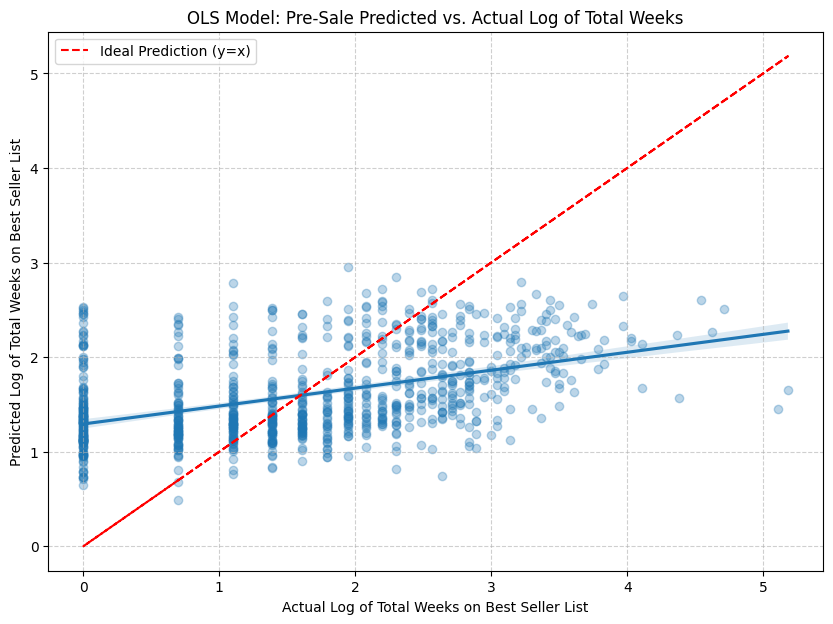

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.regplot(x=y_test, y=y_test_pred, scatter_kws={'alpha':0.3})
plt.plot(y_test, y_test, color='red', linestyle='--', label='Ideal Prediction (y=x)')
plt.xlabel("Actual Log of Total Weeks on Best Seller List")
plt.ylabel("Predicted Log of Total Weeks on Best Seller List")
plt.title("OLS Model: Pre-Sale Predicted vs. Actual Log of Total Weeks")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

#KNN MAIN MODEL

1
1.2591362404979984
2
1.1264919270314946
3
1.0338224112223455
4
0.9929295422700685
5
0.9682271150526394
6
0.9639963467119121
7
0.9576679844739532
8
0.9585176758319007
9
0.9562908842970766
10
0.9541414127559652
11
0.9488842704994552
12
0.9482161624030764
13
0.9428523859646681
14
0.9398167485297447
15
0.9402829528493692
16
0.939292238419077
17
0.9367018131878413
18
0.9365682250570142
19
0.935963853907516
20
0.9347132330299531
21
0.934213090407601
22
0.9335403822862096
23
0.9338923625995907
24
0.9341887330129157
25
0.9317972498402655
26
0.929323862901966
27
0.9297901639695352
28
0.927438647022778
29
0.9285018063085408
30
0.927100136501376
31
0.9270336743620735
32
0.9261864714359214
33
0.9270347049031354
34
0.9276339560403636
35
0.9258985808862675
36
0.9255450990291473
37
0.9265696433012451
38
0.9252820839399212
39
0.924324754766684
40
0.9240958291742419
41
0.9238871685582303
42
0.9228958160626227
43
0.9217139321627127
44
0.921848265201719
45
0.9216652615704174
46
0.9224076073037807
47
0.

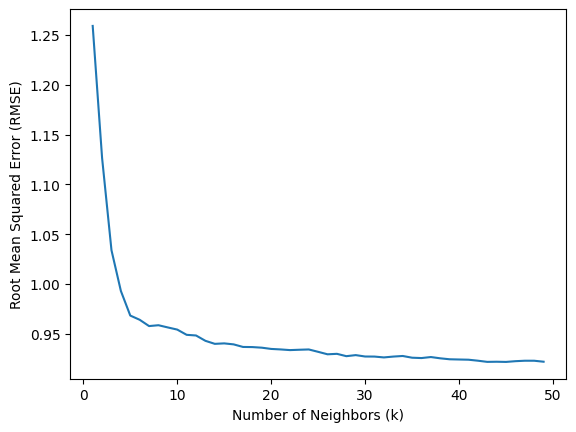

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

rmse_values=[]
k_values=list(range(1,50)) #tested range up to 50 and narrow to see which k was lowest
for k in k_values:
  model= KNeighborsRegressor(n_neighbors=k)
  model.fit(X_train, y_train)
  y_hat= model.predict(X_val)
  rmse=root_mean_squared_error(y_hat, y_val)
  print(k)
  print(rmse)
  rmse_values.append(rmse)

plt.plot(k_values, rmse_values)
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.show()


In [ ]:
#best k=7  best_rank
#best k=45 with out best_rank
k=45
model= KNeighborsRegressor(n_neighbors=k)
model.fit(X_train, y_train)
y_hat= model.predict(X_test)
rmse=root_mean_squared_error(y_hat, y_test)
print(rmse)
print(y_hat)

r_square= r2_score(y_test, y_hat)
print(f"R square KNN: {r_square}")
rmse= root_mean_squared_error(y_test, y_hat)
print(f"Root mean square error: {rmse}")
mae= mean_absolute_error(y_test, y_hat)
print(f"Mean absolute error: {mae}")

0.9438092276504813
[1.67244313 1.01747611 1.51666703 0.87236018 1.27801586 1.23111757
 1.85255035 2.41820556 1.31564124 1.90654631 1.011588   0.72481205
 2.17600126 1.0189103  2.20867979 1.89630069 1.95149555 1.86508228
 1.23975208 2.56310571 2.43923616 2.16017224 2.08779834 2.39475601
 2.53556786 1.02054562 0.8778234  2.32349677 0.95377582 1.12420743
 1.88441309 2.44794827 1.95804139 0.97011133 0.98452936 2.30928821
 0.9953965  1.67802437 2.38479748 2.18023669 2.7047051  1.600382
 1.35780549 2.05143502 2.28280186 1.16828856 1.94032933 1.60203707
 1.13972654 2.10570375 1.27186305 1.31139943 1.8818868  2.40227356
 0.97416292 1.47876345 2.85116149 1.33688025 1.11291897 1.35507766
 2.14606248 2.26654243 1.12874441 1.59107112 1.12351293 1.6760474
 1.78994397 1.37435764 1.40231522 2.18325842 1.18913224 2.33887191
 2.01204311 2.19873484 1.1275591  0.86119912 0.81303065 2.21318939
 1.50707433 2.02407902 2.64866042 2.29487782 1.59931812 0.97285535
 2.27225907 1.08956196 1.24206149 1.59279318 1

with best_rank:
- R square KNN: 0.75338140225478
- Root mean square error: 0.5585418531897538
- Mean absolute error: 0.4186240577100485

without best_rank:
- R square KNN: 0.2958214059361355
- Root mean square error: 0.9438092276504813
- Mean absolute error: 0.7663360212701079

In [ ]:
y_test_pred_original_knn = np.exp(y_hat)
y_test_actual_original_knn = np.exp(y_test)

rmse_original_scale_knn = root_mean_squared_error(y_test_actual_original_knn, y_test_pred_original_knn)

print(f"RMSE in original scale (weeks) for KNN: {rmse_original_scale_knn:.4f}")

RMSE in original scale (weeks) for KNN: 13.3822


KNN with best: RMSE in original scale (weeks) for KNN: 10.6433


KNN without best: RMSE in original scale (weeks) for KNN: 13.3822

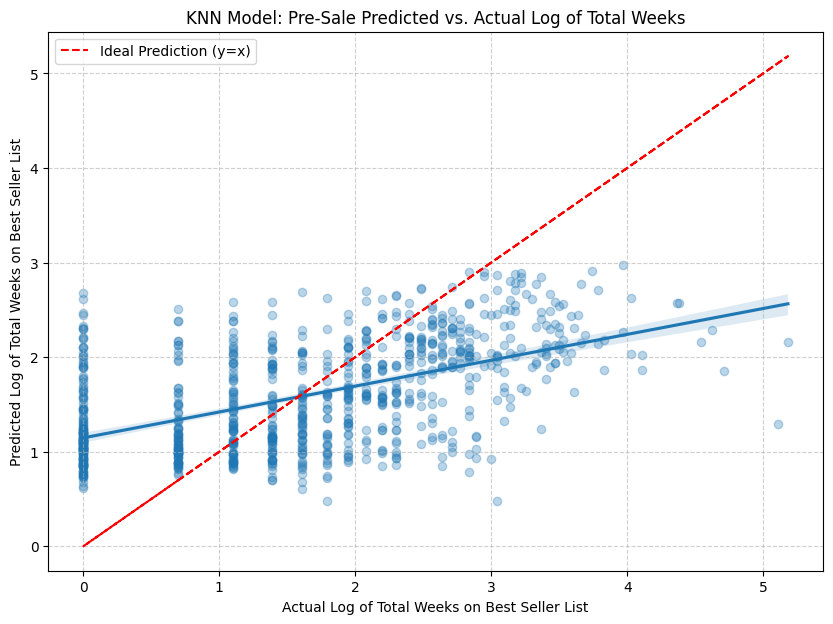

In [ ]:
plt.figure(figsize=(10, 7))
sns.regplot(x=y_test, y=y_hat, scatter_kws={'alpha':0.3})
plt.plot(y_test, y_test, color='red', linestyle='--', label='Ideal Prediction (y=x)')
plt.xlabel("Actual Log of Total Weeks on Best Seller List")
plt.ylabel("Predicted Log of Total Weeks on Best Seller List")
plt.title("KNN Model: Pre-Sale Predicted vs. Actual Log of Total Weeks")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

AUTHORS

In [ ]:
import re
import pandas as pd

def clean_author(text):
    if pd.isna(text):
        return None

    # 1. Remove everything before "by"
    text = re.sub(r'^.*?\bby\b\s*', '', text, flags=re.IGNORECASE).strip()

    # 2. Handle "with" (always secondary author → drop it)
    text = re.split(r'\s+with\s+', text, flags=re.IGNORECASE)[0].strip()

    # 3. Handle "and"
    if re.search(r'\s+and\s+', text, flags=re.IGNORECASE):
        parts = re.split(r'\s+and\s+', text, flags=re.IGNORECASE)

        # Case: same last name (e.g., "Janet and Allan Ahlberg")
        if len(parts) == 2:
            first, second = parts[0].strip(), parts[1].strip()

            first_words = first.split()
            second_words = second.split()

            if len(second_words) > 1:
                last_name = second_words[-1]
                # If first part is just a first name, attach last name
                if len(first_words) == 1:
                    return f"{first_words[0]} {last_name}"

        # Default: just take first part
        return parts[0].strip()

    return text

In [ ]:
model_df['author_clean'] = model_df['author'].apply(clean_author)

In [ ]:
model_df['author_clean'].value_counts()

,count
author_clean,
Danielle Steel,111
James Patterson,108
Clive Cussler,59
Stephen King,53
Mary Higgins Clark,47
...,...
Samantha Shannon,1
Richard Hughes,1
"""Elizabeth.",1


In [ ]:
#model_df['author'].value_counts()

with pd.option_context('display.max_rows', None):
    display(model_df['author'].value_counts())

,count
author,
Danielle Steel,111
Stephen King,49
Sandra Brown,39
Mary Higgins Clark,38
Stuart Woods,38
David Baldacci,37
Nora Roberts,36
Dean Koontz,36
John Grisham,33


In [ ]:
author_freq = pd.DataFrame()
author_freq['author']= model_df['author_clean']
author_freq = author_freq.groupby('author').size().reset_index(name='count')

#author_freq.sort_values(by='count', ascending=True)
first_time_authors = author_freq[author_freq['count'] == 1]
print(first_time_authors)
#might need to do some cleaning of the authors column


#with pd.option_context('display.max_columns', None):
    #display(author_freq)

                 author  count
0           "Elizabeth.      1
1           "Miss Read"      1
2           A. A. Milne      1
3     A. Hamilton Gibbs      1
5           A. S. Byatt      1
...                 ...    ...
1642          Yaa Gyasi      1
1643       Yangsze Choo      1
1645      Yukio Mishima      1
1647               Zane      1
1649        de Deveraux      1

[902 rows x 2 columns]


In [ ]:
print(model_df[model_df['author_clean'].str.contains('miss read', case=False, na=False)])

      book_id                 title       author  total_weeks  debut_rank  \
5518  4168576  STORM IN THE VILLAGE  "Miss Read"            1          15   

      best_rank  year        publisher  average_rating  ratings_count  ...  \
5518         14  1959  Thorndike Press            4.24            7.0  ...   

      genre_comics, graphic  genre_fantasy, paranormal  genre_fiction  \
5518                      0                          0              1   

      genre_history, historical fiction, biography  \
5518                                             0   

      genre_mystery, thriller, crime  genre_non-fiction  genre_poetry  \
5518                               0                  0             0   

      genre_romance  genre_young-adult  author_clean  
5518              0                  0   "Miss Read"  

[1 rows x 224 columns]


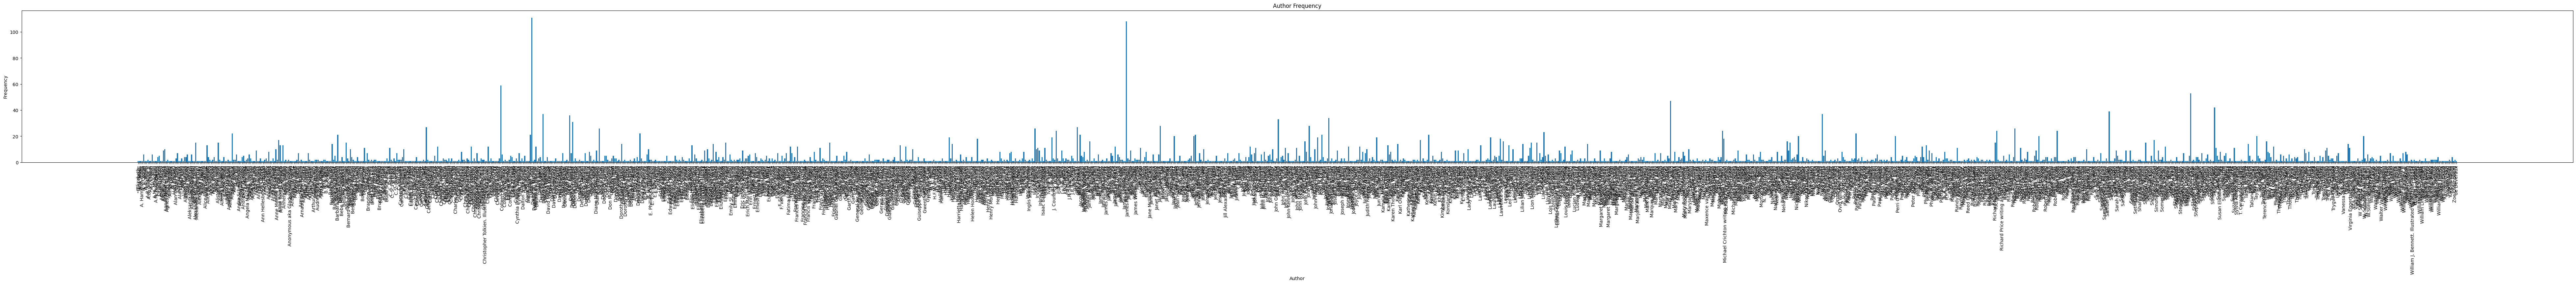

In [ ]:
#author frequency chart


plt.figure(figsize=(100, 6))
plt.bar(author_freq['author'], author_freq['count'])
plt.title('Author Frequency')
plt.xticks(rotation=90)
plt.xlabel('Author')
plt.ylabel('Frequency')
plt.show()

#FIRST TIME AUTHORS- OLS then KNN
- not including best rank!!!



In [ ]:
first_time_df= model_df[model_df['author_clean'].isin(first_time_authors['author'])]
print(f"Number of books by first_time authors: {len(first_time_df):,}")
first_time_df.head(10)

Number of books by first_time authors: 902


,book_id,title,author,total_weeks,debut_rank,best_rank,year,publisher,average_rating,ratings_count,...,"genre_comics, graphic","genre_fantasy, paranormal",genre_fiction,"genre_history, historical fiction, biography","genre_mystery, thriller, crime",genre_non-fiction,genre_poetry,genre_romance,genre_young-adult,author_clean
5,4667024,THE HELP,Kathryn Stockett,108,15,1,2009,Amy Einhorn Books,4.45,1565302.0,...,0,0,1,0,0,0,0,0,0,Kathryn Stockett
7,930,MEMOIRS OF A GEISHA,Arthur Golden,62,14,5,1997,Random House Large Print Publishing,4.08,1301962.0,...,0,0,1,0,0,0,0,0,0,Arthur Golden
8,24178,CHARLOTTE'S WEB,E.B. White,3,13,13,1952,HarperCollinsPublishers,4.15,1096929.0,...,0,0,0,0,0,0,0,0,0,E.B. White
13,18405,GONE WITH THE WIND,Margaret Mitchell,78,5,1,1936,Grand Central Publishing,4.28,887935.0,...,0,0,1,0,0,0,0,0,0,Margaret Mitchell
20,19288043,GONE GIRL,Gillian Flynn,80,9,1,2012,Broadway Books,4.03,588451.0,...,0,0,0,0,1,0,0,0,0,Gillian Flynn
28,18143977,ALL THE LIGHT WE CANNOT SEE,Anthony Doerr,132,2,1,2014,Scribner,4.31,498685.0,...,0,0,1,0,0,0,0,0,0,Anthony Doerr
35,9361589,THE NIGHT CIRCUS,Erin Morgenstern,7,11,2,2011,Doubleday,4.03,441272.0,...,0,1,0,0,0,0,0,0,0,Erin Morgenstern
40,6514,THE BELL JAR,Sylvia Plath,24,5,4,1971,Harper Perennial,3.98,407392.0,...,0,0,1,0,0,0,0,0,0,Sylvia Plath
41,2728527,THE GUERNSEY LITERARY AND POTATO PEEL PIE SOCIETY,Mary Ann Shaffer and Annie Barrows,33,8,3,2008,The Dial Press,4.12,399653.0,...,0,0,1,0,0,0,0,0,0,Mary Ann Shaffer
67,13158800,THE LIGHT BETWEEN OCEANS,M. L. Stedman,8,4,4,2012,Scribner,4.01,252365.0,...,0,0,1,0,0,0,0,0,0,M. L. Stedman


In [ ]:
#train test split and define x and y
X_fta = first_time_df[['debut_rank', 'year', 'average_rating'] + svd_cols + genre_cols] # Now including SVD features
Y_fta= first_time_df['total_weeks'] #what we want to guess based on predictors- if we want to do something else it is an easy change
y_fta=np.log(Y_fta)

X_train_fta, X_temp_fta, y_train_fta, y_temp_fta = train_test_split(X_fta, y_fta, test_size=0.3, random_state=42)
X_val_fta, X_test_fta, y_val_fta, y_test_fta = train_test_split(X_temp_fta, y_temp_fta, test_size=0.5, random_state=42)

#X_train_fta, X_test_fta, y_train_fta, y_test_fta = train_test_split(X_fta, y_fta, test_size=0.2, random_state=42)

#to see number of train vs test rows
#split 80% train 20% test
print(f"Training rows: {X_train_fta.shape[0]:,}")
print(f"Validation rows: {X_val_fta.shape[0]:,}")
print(f"Testing rows:  {X_test_fta.shape[0]:,}")

Training rows: 631
Validation rows: 135
Testing rows:  136


#OLS- first time

In [ ]:
X_train_fta_sm= sm.add_constant(X_train_fta)
X_test_fta_sm= sm.add_constant(X_test_fta)
ols_model_fta= sm.OLS(y_train_fta, X_train_fta_sm).fit()
print(ols_model_fta.summary())

                            OLS Regression Results                            
Dep. Variable:            total_weeks   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     4.727
Date:                Sat, 09 May 2026   Prob (F-statistic):           6.48e-10
Time:                        18:39:14   Log-Likelihood:                -950.82
No. Observations:                 631   AIC:                             1940.
Df Residuals:                     612   BIC:                             2024.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [ ]:
# Make predictions on the test set

y_test_fta_pred= ols_model_fta.predict(X_test_fta_sm) #use the same model on test data

# Evaluate the model- change to  rmse
mae_fta= mean_absolute_error(y_test_fta, y_test_fta_pred)
rmse_fta= root_mean_squared_error(y_test_fta, y_test_fta_pred)
r2_fta= r2_score(y_test_fta, y_test_fta_pred)

print(f"Mean Absolute Error (MAE): {mae_fta:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_fta:.4f}")
print(f"R-squared (R2): {r2_fta:.4f}")

Mean Absolute Error (MAE): 0.9296
Root Mean Squared Error (RMSE): 1.1130
R-squared (R2): 0.0079


OLS fta:
- Mean Absolute Error (MAE): 0.9296
- Root Mean Squared Error (RMSE): 1.1130
- R-squared (R2): 0.0079

In [ ]:
# Convert log-transformed predictions and actuals back to original scale (weeks)
y_test_pred_original_fta = np.exp(y_test_fta_pred)
y_test_actual_original_fta = np.exp(y_test_fta)

# Calculate RMSE on original scale
rmse_original_scale_fta = root_mean_squared_error(y_test_actual_original_fta, y_test_pred_original_fta)

print(f"RMSE in original scale (weeks): {rmse_original_scale_fta:.4f}")

RMSE in original scale (weeks): 13.6814


RMSE in original scale (weeks): 13.6814

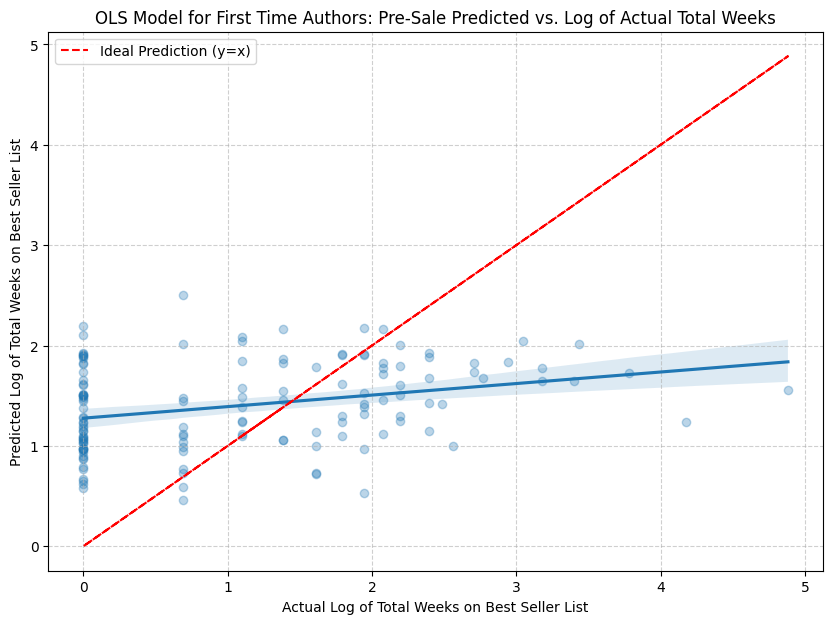

In [ ]:
#ai generated
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.regplot(x=y_test_fta, y=y_test_fta_pred, scatter_kws={'alpha':0.3})
plt.plot(y_test_fta, y_test_fta, color='red', linestyle='--', label='Ideal Prediction (y=x)')
plt.xlabel("Actual Log of Total Weeks on Best Seller List")
plt.ylabel("Predicted Log of Total Weeks on Best Seller List")
plt.title("OLS Model for First Time Authors: Pre-Sale Predicted vs. Log of Actual Total Weeks")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

#KNN- first time

1
1.563775035520155
2
1.3072573854432612
3
1.206755131855952
4
1.1426837721297043
5
1.167306132262248
6
1.1605595541144897
7
1.1559949190999055
8
1.1464438682509048
9
1.1380052450762408
10
1.1191171260665929
11
1.1191862173107097
12
1.108862760885474
13
1.1081936343998446
14
1.1016757827922314
15
1.0987673615846039
16
1.0925334373378468
17
1.087364892984589
18
1.0871805880310967
19
1.0812290117089647
20
1.0794025788625052
21
1.0787425934755674
22
1.0778293442370674
23
1.0797020367034849
24
1.0701019117642077
25
1.0698502787250543
26
1.0751037307190763
27
1.08503157164784
28
1.0865030690063766
29
1.084811705302046
30
1.0861980940705631
31
1.092950254731364
32
1.096155004282095
33
1.0989943815563727
34
1.1014176703328946
35
1.1024079201998418
36
1.1063745276494659
37
1.1071589183271844
38
1.1043754219904536
39
1.1047902576465902
40
1.1013688951897427
41
1.0997413049728797
42
1.097552816194358
43
1.0970908438048805
44
1.0981739245113395
45
1.100816214077551
46
1.1013221251106897
47
1.1024

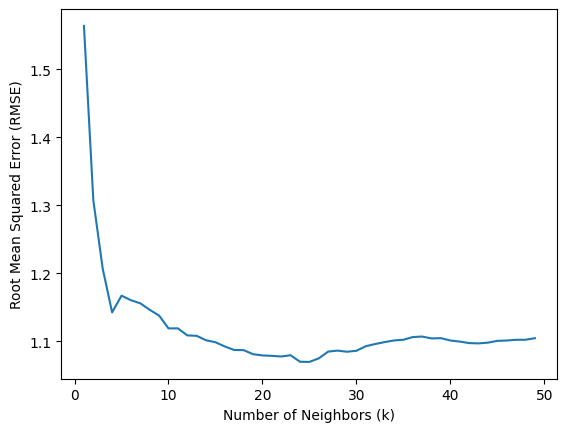

In [ ]:
fta_rmse_values=[]
fta_k_values=list(range(1,50))
for k in fta_k_values:
  fta_model= KNeighborsRegressor(n_neighbors=k)
  fta_model.fit(X_train_fta, y_train_fta)
  y_hat_fta= fta_model.predict(X_val_fta)
  rmse_fta=root_mean_squared_error(y_hat_fta, y_val_fta)
  print(k)
  print(rmse_fta)
  fta_rmse_values.append(rmse_fta)

plt.plot(fta_k_values, fta_rmse_values)
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.show()

In [ ]:
#best k=25 without best
k=25
fta_model= KNeighborsRegressor(n_neighbors=k)
fta_model.fit(X_train_fta, y_train_fta)
y_hat_fta= fta_model.predict(X_test_fta)
rmse_fta=root_mean_squared_error(y_hat_fta, y_test_fta)
print(rmse_fta)
print(y_hat_fta)

r_square_fta= r2_score(y_test_fta, y_hat_fta)
print(f"R square KNN: {r_square_fta}")
rmse_fta= root_mean_squared_error(y_test_fta, y_hat_fta)
print(f"Root mean square error: {rmse_fta}")
mae_fta= mean_absolute_error(y_test_fta, y_hat_fta)
print(f"Mean absolute error: {mae_fta}")

1.1012832137799113
[1.88504445 1.92837224 2.3695809  0.94987452 1.26340277 0.98935537
 1.28614698 1.88504445 1.13566991 1.30382029 0.92806544 2.01997913
 0.88329618 1.26503565 0.71249851 1.30246423 0.76541849 1.10275821
 1.9565315  1.18350386 2.21282124 1.30382029 1.08578732 0.76509976
 1.4541038  1.06165568 1.82596725 1.00609011 1.90079935 1.73502829
 1.59861645 1.90744232 1.78517966 1.32289725 0.99632951 1.25923914
 0.75359248 2.2792118  0.98749457 0.97528578 1.92993234 0.67683975
 2.19912979 0.60611803 1.67004099 2.25323282 0.72844814 0.84415381
 1.89201395 0.70456564 1.28614698 0.94014377 2.16738305 0.78389991
 1.79804974 1.55676775 0.94014377 0.70162116 1.97859508 1.59162002
 1.8000639  2.23914411 1.8517367  1.95594305 1.98764242 1.42672129
 0.88211703 1.99656816 1.23132849 2.19566041 0.89417352 0.90041369
 1.88494394 2.09336643 2.13541582 0.8569661  1.1577065  0.88777958
 0.93441973 1.19335988 2.05871262 1.6108194  1.74787739 1.97196801
 0.84488778 0.9495115  1.83333857 1.7782389

FTA OLS:
- R square KNN: 0.02862196219967683
- Root mean square error: 1.1012832137799113
- Mean absolute error: 0.8830864702599324

In [ ]:
y_test_pred_original_knn_fta = np.exp(y_hat_fta)
y_test_actual_original_knn_fta = np.exp(y_test_fta)

rmse_original_scale_knn_fta = root_mean_squared_error(y_test_actual_original_knn_fta, y_test_pred_original_knn_fta)

print(f"RMSE in original scale (weeks) for KNN: {rmse_original_scale_knn_fta:.4f}")

RMSE in original scale (weeks) for KNN: 13.7151


FTA OLS: RMSE in original scale (weeks) for KNN: 13.7151

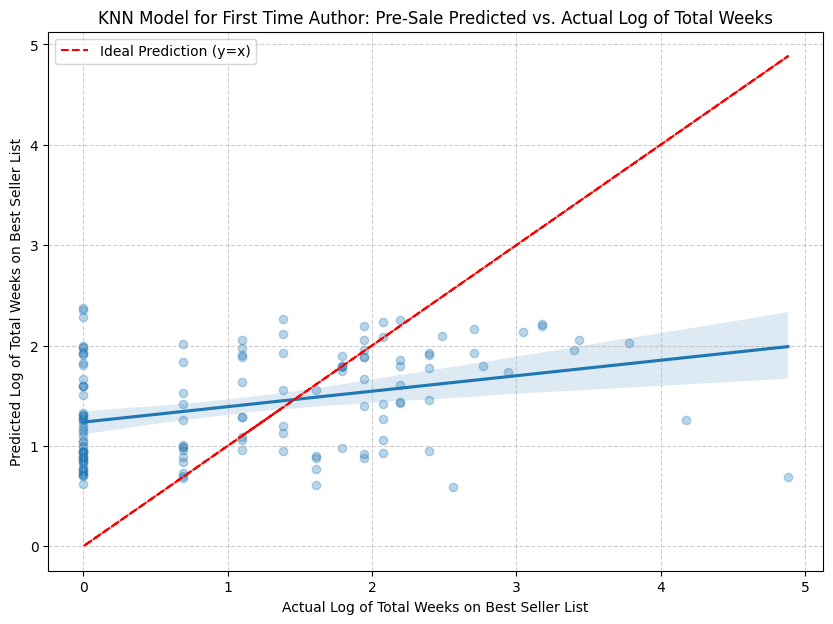

In [ ]:
#First time authors prediction
plt.figure(figsize=(10, 7))
sns.regplot(x=y_test_fta, y=y_hat_fta, scatter_kws={'alpha':0.3})
plt.plot(y_test_fta, y_test_fta, color='red', linestyle='--', label='Ideal Prediction (y=x)')
plt.xlabel("Actual Log of Total Weeks on Best Seller List")
plt.ylabel("Predicted Log of Total Weeks on Best Seller List")
plt.title("KNN Model for First Time Author: Pre-Sale Predicted vs. Actual Log of Total Weeks")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Repeat authors

In [ ]:
repeated_authors = author_freq[author_freq['count'] > 1]['author']
returner_df = model_df[model_df['author_clean'].isin(repeated_authors)]

print(f"Number of books by returning authors: {len(returner_df):,}")
returner_df.head()

Number of books by returning authors: 4,820


,book_id,title,author,total_weeks,debut_rank,best_rank,year,publisher,average_rating,ratings_count,...,"genre_comics, graphic","genre_fantasy, paranormal",genre_fiction,"genre_history, historical fiction, biography","genre_mystery, thriller, crime",genre_non-fiction,genre_poetry,genre_romance,genre_young-adult,author_clean
0,2657,TO KILL A MOCKINGBIRD,Harper Lee,98,14,2,1960,Harper Perennial Modern Classics,4.26,3255518.0,...,0,0,1,0,0,0,0,0,0,Harper Lee
1,5907,THE HOBBIT,J.R.R. Tolkien,2,3,12,1977,Houghton Mifflin,4.25,2099680.0,...,0,1,0,0,0,0,0,0,0,J.R.R. Tolkien
2,5107,THE CATCHER IN THE RYE,J.D. Salinger,29,15,4,1951,Back Bay Books,3.79,2086945.0,...,0,0,1,0,0,0,0,0,0,J.D. Salinger
3,7613,ANIMAL FARM,George Orwell,6,8,7,1946,NAL,3.88,1928931.0,...,0,0,1,0,0,0,0,0,0,George Orwell
4,12232938,THE LOVELY BONES,Alice Sebold,65,6,1,2002,"Little, Brown and Company",3.78,1628726.0,...,0,0,1,0,0,0,0,0,0,Alice Sebold


In [ ]:
#train test split and define x and y
X_ret = returner_df[['debut_rank', 'year', 'average_rating'] + svd_cols + genre_cols] # Now including SVD features
Y_ret= returner_df['total_weeks'] #what we want to guess based on predictors- if we want to do something else it is an easy change
y_ret=np.log(Y_ret)

X_train_ret, X_temp_ret, y_train_ret, y_temp_ret = train_test_split(X_ret, y_ret, test_size=0.3, random_state=42)
X_val_ret, X_test_ret, y_val_ret, y_test_ret = train_test_split(X_temp_ret, y_temp_ret, test_size=0.5, random_state=42)
#X_train_ret, X_test_ret, y_train_ret, y_test_ret = train_test_split(X_ret, y_ret, test_size=0.2, random_state=42)

#to see number of train vs test rows
#split 80% train 20% test
print(f"Training rows: {X_train_ret.shape[0]:,}")
print(f"Validation rows: {X_val_ret.shape[0]:,}")
print(f"Testing rows:  {X_test_ret.shape[0]:,}")

Training rows: 3,374
Validation rows: 723
Testing rows:  723


#OLS - return

In [ ]:
X_train_ret_sm= sm.add_constant(X_train_ret)
X_test_ret_sm= sm.add_constant(X_test_ret)
ols_model_ret= sm.OLS(y_train_ret, X_train_ret_sm).fit()
print(ols_model_ret.summary())

                            OLS Regression Results                            
Dep. Variable:            total_weeks   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     49.49
Date:                Sat, 09 May 2026   Prob (F-statistic):          1.65e-156
Time:                        18:39:15   Log-Likelihood:                -4660.4
No. Observations:                3374   AIC:                             9359.
Df Residuals:                    3355   BIC:                             9475.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [ ]:
# Make predictions on the test set

y_test_ret_pred= ols_model_ret.predict(X_test_ret_sm) #use the same model on test data

# Evaluate the model- change to  rmse
mae_ret= mean_absolute_error(y_test_ret, y_test_ret_pred)
rmse_ret= root_mean_squared_error(y_test_ret, y_test_ret_pred)
r2_ret= r2_score(y_test_ret, y_test_ret_pred)

print(f"Mean Absolute Error (MAE): {mae_ret:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ret:.4f}")
print(f"R-squared (R2): {r2_ret:.4f}")

Mean Absolute Error (MAE): 0.8115
Root Mean Squared Error (RMSE): 0.9963
R-squared (R2): 0.1906


OLS returning:
- Mean Absolute Error (MAE): 0.8115
- Root Mean Squared Error (RMSE): 0.9963
- R-squared (R2): 0.1906

In [ ]:
# Convert log-transformed predictions and actuals back to original scale (weeks)
y_test_pred_original_ret = np.exp(y_test_ret_pred)
y_test_actual_original_ret = np.exp(y_test_ret)

# Calculate RMSE on original scale
rmse_original_scale_ret = root_mean_squared_error(y_test_actual_original_ret, y_test_pred_original_ret)

print(f"RMSE in original scale (weeks): {rmse_original_scale_ret:.4f}")

RMSE in original scale (weeks): 13.3545


RMSE OLS returning: RMSE in original scale (weeks): 13.3545

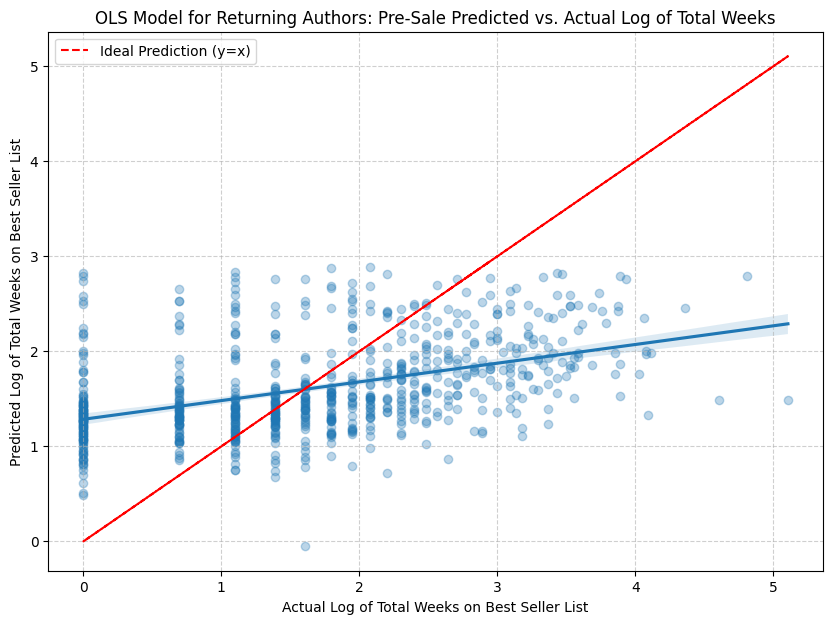

In [ ]:
#ai generated
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.regplot(x=y_test_ret, y=y_test_ret_pred, scatter_kws={'alpha':0.3})
plt.plot(y_test_ret, y_test_ret, color='red', linestyle='--', label='Ideal Prediction (y=x)')
plt.xlabel("Actual Log of Total Weeks on Best Seller List")
plt.ylabel("Predicted Log of Total Weeks on Best Seller List")
plt.title("OLS Model for Returning Authors: Pre-Sale Predicted vs. Actual Log of Total Weeks")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

#KNN Returning

1
1.2199265981158747
2
1.0661878275089671
3
0.9978574591437248
4
0.9606863716609871
5
0.9512780433349882
6
0.9399298365284824
7
0.9246987671591517
8
0.9220671271487915
9
0.9152572385925442
10
0.9130868135391358
11
0.9049152689267251
12
0.9083519295440453
13
0.9077733452331526
14
0.9080939206854587
15
0.9027535677404059
16
0.9043992751503938
17
0.9055046905742691
18
0.9063423901107588
19
0.9052199829638709
20
0.9039681344185093
21
0.9086537597383405
22
0.9078752805975303
23
0.9099934288981598
24
0.9080495395781649
25
0.9073209433652605
26
0.90753744105667
27
0.9047052437045826
28
0.9065704528759637
29
0.9045861091415306
30
0.9048045387040173
31
0.9053854076700937
32
0.9059191827740416
33
0.9063896317380404
34
0.9049676856115645
35
0.906005041490427
36
0.9042803491260829
37
0.9031742080707093
38
0.9023774435925784
39
0.9029991813922935
40
0.9053939033089695
41
0.9065522384150925
42
0.9064703880546171
43
0.9070957947818699
44
0.9069257201769192
45
0.9071678083663267
46
0.9077144087623561


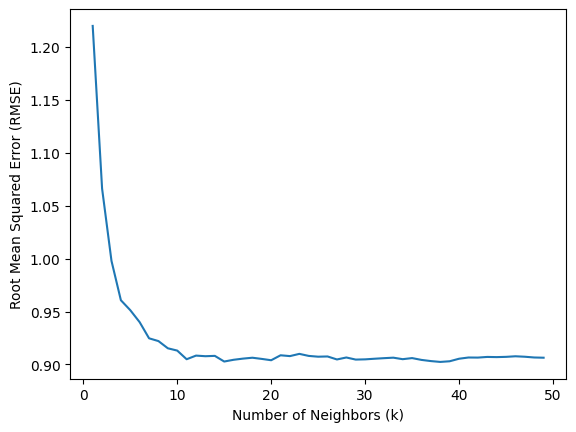

In [ ]:
ret_rmse_values=[]
ret_k_values=list(range(1,50))
for k in ret_k_values:
  ret_model= KNeighborsRegressor(n_neighbors=k)
  ret_model.fit(X_train_ret, y_train_ret)
  y_hat_ret= ret_model.predict(X_val_ret)
  rmse_ret=root_mean_squared_error(y_hat_ret, y_val_ret)
  print(k)
  print(rmse_ret)
  ret_rmse_values.append(rmse_ret)

plt.plot(ret_k_values, ret_rmse_values)
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.show()

In [ ]:
#best k=38
k=38
ret_model= KNeighborsRegressor(n_neighbors=k)
ret_model.fit(X_train_ret, y_train_ret)
y_hat_ret= ret_model.predict(X_test_ret)
rmse_ret=root_mean_squared_error(y_hat_ret, y_test_ret)
print(rmse_ret)
print(y_hat_ret)

r_square_ret= r2_score(y_test_ret, y_hat_ret)
print(f"R square KNN: {r_square_ret}")
rmse_ret= root_mean_squared_error(y_test_ret, y_hat_ret)
print(f"Root mean square error: {rmse_ret}")
mae_ret= mean_absolute_error(y_test_ret, y_hat_ret)
print(f"Mean absolute error: {mae_ret}")

0.9323220483297759
[2.54133011 2.06955657 2.78190192 2.05537476 2.32906263 1.87286985
 0.78540594 1.31314339 1.09992396 0.95487418 2.3163701  1.78276282
 1.31979928 1.38190513 1.83068314 1.5132691  2.7143338  1.3107656
 1.6610066  1.87461468 1.33046512 2.69760266 2.09609632 2.26144907
 1.50339792 1.42000021 1.70750608 1.64352631 0.96277167 0.84253508
 2.09877296 1.27966905 1.06249191 1.57642352 1.18767103 2.26427294
 1.03660781 0.9626495  1.06850099 2.78241693 2.34569621 0.99680843
 1.09602672 2.65197509 1.63455456 2.05439403 2.15278507 1.57710134
 1.96537879 1.4707173  2.04900567 1.61807227 0.83996075 1.3647844
 1.15361398 1.6600883  2.02099151 2.35957217 1.20841722 1.13334196
 2.36308009 0.99722781 0.98893443 2.17043932 1.29208634 2.90780552
 1.2576302  1.25564365 1.6152755  1.20146681 3.00466862 1.77615534
 1.12660477 2.62069652 2.23936823 2.58148306 0.78146656 1.43727072
 2.02722873 0.84309303 2.44060412 2.12329158 2.55671492 1.14360368
 1.27426006 2.25825256 1.27310429 0.96939122 

repeat KNN:
- R square KNN: 0.29124997697324007
- Root mean square error: 0.9323220483297759
- Mean absolute error: 0.7380821227828526

In [ ]:
y_test_pred_original_knn_ret= np.exp(y_hat_ret)
y_test_actual_original_knn_ret = np.exp(y_test_ret)

rmse_original_scale_knn_ret = root_mean_squared_error(y_test_actual_original_knn_ret, y_test_pred_original_knn_ret)

print(f"RMSE in original scale (weeks) for KNN: {rmse_original_scale_knn_ret:.4f}")

RMSE in original scale (weeks) for KNN: 12.9174


Returning KNN: RMSE in original scale (weeks) for KNN: 12.9174

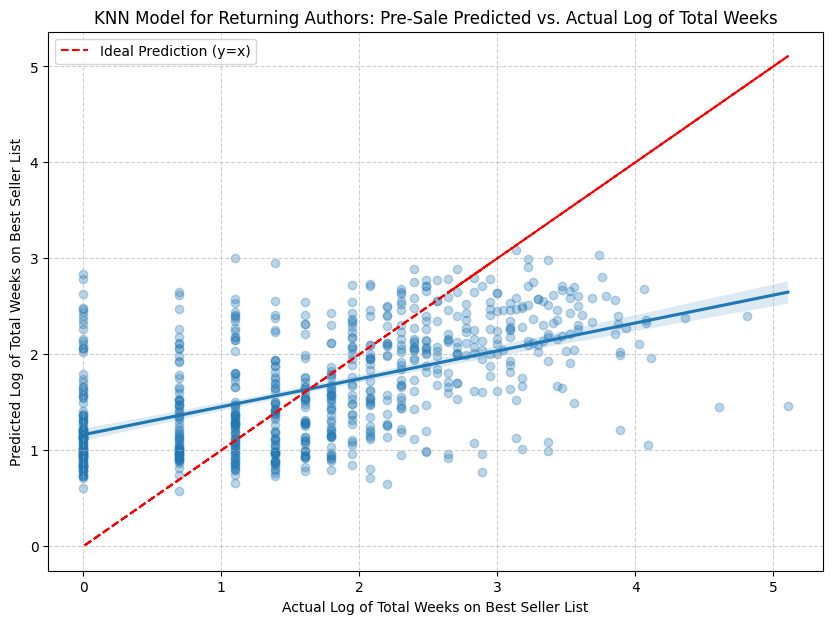

In [ ]:
#returning authors prediction
plt.figure(figsize=(10, 7))
sns.regplot(x=y_test_ret, y=y_hat_ret, scatter_kws={'alpha':0.3})
plt.plot(y_test_ret, y_test_ret, color='red', linestyle='--', label='Ideal Prediction (y=x)')
plt.xlabel("Actual Log of Total Weeks on Best Seller List")
plt.ylabel("Predicted Log of Total Weeks on Best Seller List")
plt.title("KNN Model for Returning Authors: Pre-Sale Predicted vs. Actual Log of Total Weeks")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

#distribution of weeks histogram more explicitly and for model_df

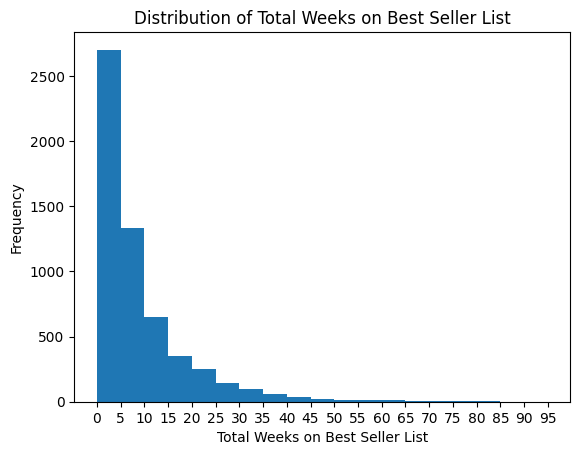

In [ ]:
weeks=model_df[['total_weeks']]

import numpy as np
import matplotlib.pyplot as plt

bins = np.arange(0, 100, 5)  # bins: 0–10, 10–20, etc.
plt.hist(weeks, bins=bins)
plt.xlabel("Total Weeks on Best Seller List")
plt.ylabel("Frequency")
plt.title("Distribution of Total Weeks on Best Seller List")

plt.xticks(bins)  # show bin edges on x-axis
plt.show()
#weeks.hist(bins=20)
